## 🛡️ SensorGuard – Modélisation de la prédiction de panne
Ce notebook couvre l’ensemble du processus de modélisation visant à prédire les pannes de machines dans un délai de 7 jours, à partir de données issues de capteurs industriels. L’objectif est de construire un modèle fiable, interprétable et utilisable en conditions réelles pour anticiper les défaillances critiques.

### 📥 Importation des bibliothèques nécessaires et chargement du jeu de données

In [1]:
import joblib
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.feature_selection import VarianceThreshold

In [2]:
csv_path = "../data/factory_sensor_simulator_2040.csv"

try:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"❌ Fichier non trouvé: {csv_path}")
    df = pd.read_csv(csv_path, low_memory=False)
    print("✅ CSV file chargé avec succès.")
    print(f"📊 Nombre d'échantillons chargés: {df.shape[0]}")
    display(df.head())
except FileNotFoundError as e:
    print(e)

✅ CSV file chargé avec succès.
📊 Nombre d'échantillons chargés: 500000


,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0


### 🧹 Nettoyage du jeu de données
Le but est de faciliter et accélerer l'apprentissage des modèles de machine learning

#### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Suppression des colonnes contenant trop de valeurs manquantes*

In [3]:
# Supprimer les colonnes contenant plus de 30 % de valeurs manquantes pour nettoyer l'espace des variables
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.3].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"🗑️ Colonnes supprimées (>30 % de valeurs manquantes) : {cols_to_drop}")

🗑️ Colonnes supprimées (>30 % de valeurs manquantes) : ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']


##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Suppression des lignes contenant encore des valeurs manquantes*

In [4]:
# Supprimer les lignes contenant encore des valeurs manquantes pour garantir des données prêtes à l'entraînement
before_rows = df.shape[0]
df.dropna(inplace=True)
after_rows = df.shape[0]
print(f"🧹 Nombre de lignes supprimées (valeurs manquantes) : {before_rows - after_rows}")

🧹 Nombre de lignes supprimées (valeurs manquantes) : 10


##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Normalisation des types de données*

In [5]:
# 1- Convertir les colonnes booléennes en entiers pour assurer la compatibilité avec les modèles
converted_bool_cols = []
for col in df.columns:
    if df[col].dropna().isin([True, False]).all():
        df[col] = df[col].astype(bool).astype(int)
        converted_bool_cols.append(col)
        print(f"🔁 Conversion booléen → entier : colonne {col}, valeurs uniques :", df[col].unique())

# 2- Identifier les colonnes de type float contenant uniquement des valeurs entières
float_cols = df.select_dtypes(include=["float"]).columns

float_to_int_candidates = []
for col in float_cols:
    if df[col].dropna().apply(float.is_integer).all():
        float_to_int_candidates.append(col)

if float_to_int_candidates:
    print(f"🔁 Colonnes float converties en int (valeurs entières uniquement) : {float_to_int_candidates}")
    df[float_to_int_candidates] = df[float_to_int_candidates].astype("int")

🔁 Conversion booléen → entier : colonne AI_Supervision, valeurs uniques : [1 0]
🔁 Conversion booléen → entier : colonne Failure_Within_7_Days, valeurs uniques : [0 1]
🔁 Colonnes float converties en int (valeurs entières uniquement) : ['Remaining_Useful_Life_days']


##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Aperçu du jeu de données nettoyé*

In [6]:
print("✅ Résumé du jeu de données nettoyé :")
print(f"   🔸 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"   🔸 Colonnes supprimées : {cols_to_drop}")
print(f"   🔸 Lignes supprimées : {before_rows - after_rows}")
print(f"   🔸 Colonnes booléennes converties (en int) : {converted_bool_cols}")

display(df.head())

✅ Résumé du jeu de données nettoyé :
   🔸 Dimensions : 499990 lignes × 18 colonnes
   🔸 Colonnes supprimées : ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']
   🔸 Lignes supprimées : 10
   🔸 Colonnes booléennes converties (en int) : ['AI_Supervision', 'Failure_Within_7_Days']


,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,1,3,162,0,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,1,4,147,0,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,1,6,0,1,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,0,4,161,0,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,0,1,765,0,0


### ⚖️ Gestion de la distribution des classes
Un déséquilibre important peut fausser l'apprentissage du modèle

##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Aperçu de la distribution des classes*

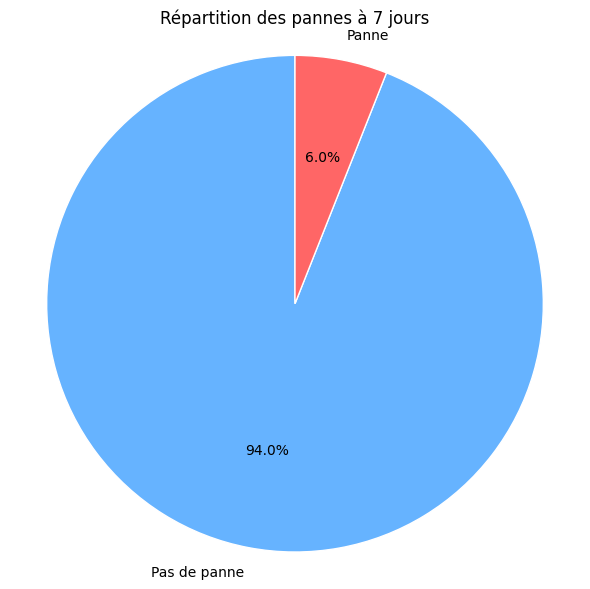

In [7]:
# Visualiser l’équilibre des classes avec un graphique circulaire
labels = ["Pas de panne", "Panne"]
sizes = df["Failure_Within_7_Days"].value_counts()
colors = ["#66b3ff", "#ff6666"]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Répartition des pannes à 7 jours")
plt.axis("equal")
plt.tight_layout()
plt.show()

##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Nous cherchons à atteindre un équilibre 50/50 afin de garantir que notre modèle s'entraîne sur des données représentatives pour chaque classe*

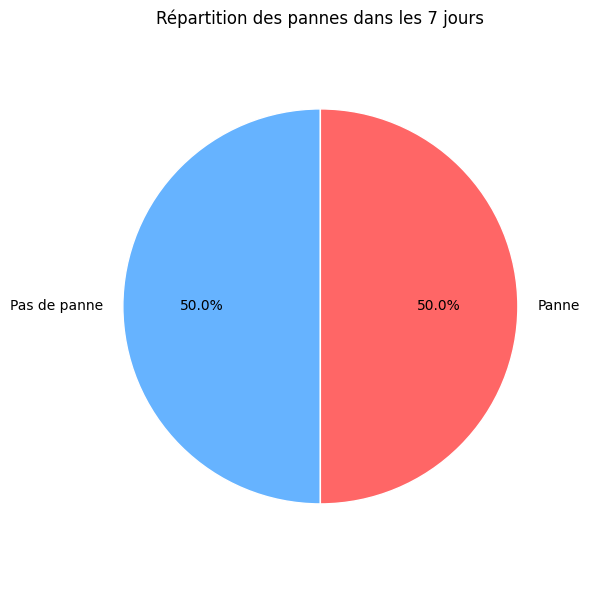

✅ Dataset rééquilibré :
Failure_Within_7_Days
0    30027
1    30027
Name: count, dtype: int64
📊 Nouvelle dimension : (60054, 18)


In [8]:
# Rééquilibrer le dataset pour obtenir une distribution 50/50 entre les classes
count_true = df[df["Failure_Within_7_Days"] == True].shape[0]
count_false = df[df["Failure_Within_7_Days"] == False].shape[0]

# Sous-échantillonnage de la classe majoritaire (False)
df_false_sampled = df[df["Failure_Within_7_Days"] == False].sample(
    count_true, random_state=42
)
df_true = df[df["Failure_Within_7_Days"] == True]

# Concaténation pour obtenir un DataFrame équilibré
df = (
    pd.concat([df_false_sampled, df_true])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Visualiser la distribution des classes avec un diagramme circulaire
labels = ["Pas de panne", "Panne"]
sizes = df["Failure_Within_7_Days"].value_counts()
colors = ["#66b3ff", "#ff6666"]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Répartition des pannes dans les 7 jours")
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"✅ Dataset rééquilibré :\n{df['Failure_Within_7_Days'].value_counts()}")
print("📊 Nouvelle dimension :", df.shape)


### 📊 Distribution des variables
Visualiser la distribution de toutes les variables numériques à l’aide d’histogrammes permet de mieux comprendre la structure du jeu de données.<br>Cela apporte un contexte utile avant toute sélection de variables ou phase d’entraînement du modèle.

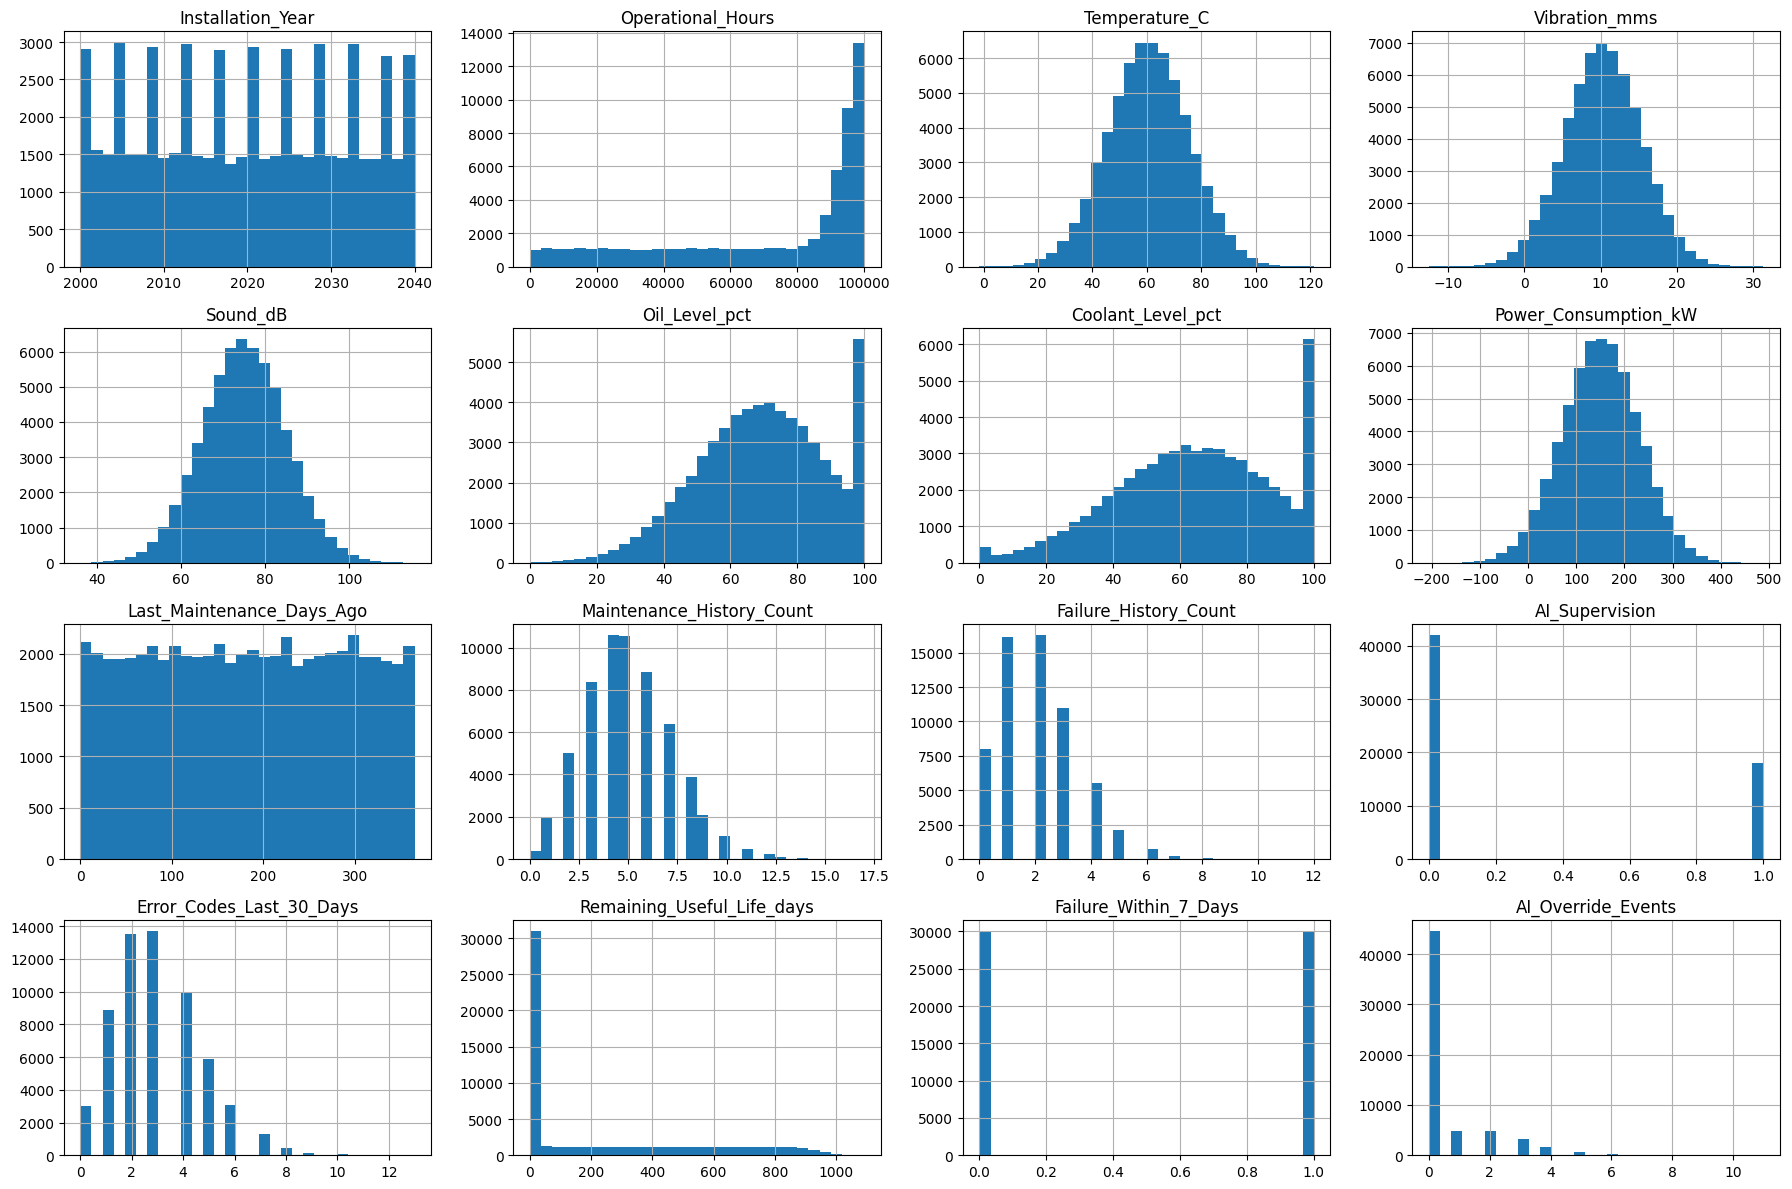

In [9]:
# Afficher les histogrammes pour les variables numériques
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(bins=30, figsize=(18, 12))
plt.tight_layout()
plt.show()

### 📈  Matrice de corrélation
Calcul et visualisation de la matrice de corrélation pour analyser les relations linéaires entre les variables numériques.<br> Les fortes corrélations positives ou négatives orientent les choix de sélection des variables.

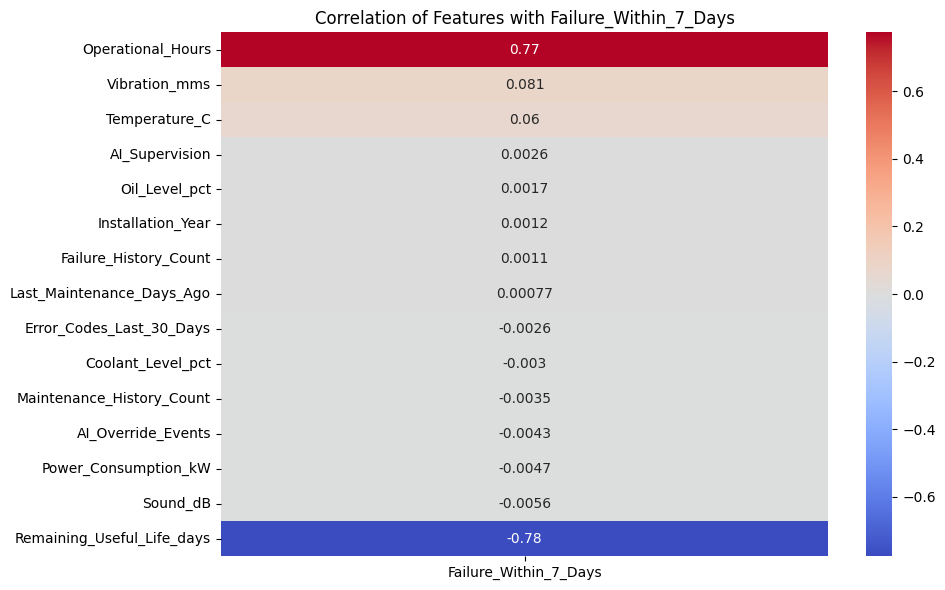

In [10]:
# Compute correlation matrix (numeric only)
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.drop(
    "Failure_Within_7_Days", errors="ignore"
)
corr_matrix = df[numeric_cols.tolist() + ["Failure_Within_7_Days"]].corr()

# Get correlation of all features with the target
target_corr = corr_matrix["Failure_Within_7_Days"].drop("Failure_Within_7_Days")

# Plot sorted correlations
plt.figure(figsize=(10, 6))
sns.heatmap(
    target_corr.to_frame().sort_values(by="Failure_Within_7_Days", ascending=False),
    annot=True,
    cmap="coolwarm",
)
plt.title("Correlation of Features with Failure_Within_7_Days")
plt.tight_layout()
plt.show()

#### 🎯 Sélection des variables à partir de leur distribution et de leur corrélation

##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Suppression des variables avec une variance faible (seuil 0.01)*

In [11]:
# Calculer la variance des colonnes numériques
selector = VarianceThreshold(threshold=0.01)
selector.fit(df[numeric_cols])

# Conserver uniquement les colonnes avec une variance suffisante
high_variance_cols = [
    col for col, keep in zip(numeric_cols, selector.get_support()) if keep
]

print("📌 Variables retenues avec un seuil de variance de 0,01 :")
for col in high_variance_cols:
    print(f" - {col}")

# Mettre à jour le DataFrame pour ne conserver que les variables à forte variance
df = df[high_variance_cols + ["Failure_Within_7_Days"]]

📌 Variables retenues avec un seuil de variance de 0,01 :
 - Installation_Year
 - Operational_Hours
 - Temperature_C
 - Vibration_mms
 - Sound_dB
 - Oil_Level_pct
 - Coolant_Level_pct
 - Power_Consumption_kW
 - Last_Maintenance_Days_Ago
 - Maintenance_History_Count
 - Failure_History_Count
 - AI_Supervision
 - Error_Codes_Last_30_Days
 - Remaining_Useful_Life_days
 - AI_Override_Events


##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Éviter les fuites de données en supprimmant des variables trop directement liées à la cible*

In [12]:
# Exclure les variables sujettes à des fuites de données
leakage_features = ["Remaining_Useful_Life_days"]
target_corr = target_corr.drop(labels=leakage_features, errors="ignore")

##### 🔹 &nbsp;&nbsp;&nbsp;&nbsp;*Sélection des variables pertinentes en fonction de leur corrélation avec la cible (seuil 0,05)*

In [13]:
# Sélectionner les variables ayant une corrélation absolue supérieure à 0,05
corr_threshold = 0.05
relevant_features = (
    target_corr[abs(target_corr) > corr_threshold]
    .sort_values(ascending=False)
    .index.tolist()
)

# Définir les variables explicatives (features) et la cible (target)
features = relevant_features
X = df[features]
y = df["Failure_Within_7_Days"]

# Afficher les variables retenues et leur corrélation
print("📌 Variables sélectionnées avec une corrélation > 0,05 :")
for feat in features:
    print(f" - {feat} (corr = {target_corr[feat]:.3f})")
print(f"\n✅ Nombre total de variables sélectionnées : {len(features)} : {features}")

📌 Variables sélectionnées avec une corrélation > 0,05 :
 - Operational_Hours (corr = 0.775)
 - Vibration_mms (corr = 0.081)
 - Temperature_C (corr = 0.060)

✅ Nombre total de variables sélectionnées : 3 : ['Operational_Hours', 'Vibration_mms', 'Temperature_C']


### ✂️ Séparation des données et mise à l’échelle
Le jeu de données est divisé en 80 % pour l’entraînement et 20 % pour le test, en respectant la proportion des classes (stratification).<br>Les données sont ensuite standardisées à l’aide d’un scaler ajusté uniquement sur l’ensemble d’entraînement, puis appliqué aux deux ensembles pour éviter toute fuite de données.

In [14]:
# Séparation entraînement/test avec stratification pour conserver l'équilibre des classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisation des données (centrage et réduction)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)   # Ajustement sur le set d'entraînement
X_test_scaled = scaler.transform(X_test.values)         # Application au set de test

###  🏋️ Entrainement et évaluation des modèles 

#### &nbsp;*Nous avons sélectionné la régression logistique, le Support Vector Machine (SVM) et la forêt aléatoire pour cette tâche de classification binaire, en raison de leurs forces complémentaires:*

##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- **Logistic Regression** est un modèle de base simple, interprétable et efficace pour la classification binaire.<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Elle permet d’interpréter facilement les liens entre variables et cible, tout en servant de référence pour comparer les autres modèles.

##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- **Support Vector Machine (SVM)** est particulièrement adapté à la classification binaire sur des jeux de données de petite à moyenne taille.<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Il est efficace dans des espaces de grande dimension et robuste aux valeurs aberrante.<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Ils sont efficaces pour des classes bien séparées et s’adaptent aux déséquilibres via un ajustement des pondérations.

##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- **Random Forest** réduit la variance grâce à l’agrégation d’un ensemble d’arbres de décision.<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Elle est capable de modéliser des frontières de décision complexes sans supposer de relation linéaire entre les variables.<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Il offre de bonnes performances avec peu de variables et permet d’identifier les plus influentes pour l’interprétation du modèle.

##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- ***XGBoost*** est un algorithme de boosting puissant et rapide, qui combine des arbres faibles de manière séquentielle<br>>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;pour corriger les erreurs précédentes, offrant d'excellentes performances sur les données tabulaires, même en présence de bruit ou de déséquilibres.


🎯 Entraînement du modèle : Régression Logistique...

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      6006
           1       0.92      0.97      0.95      6005

    accuracy                           0.95     12011
   macro avg       0.95      0.95      0.95     12011
weighted avg       0.95      0.95      0.95     12011



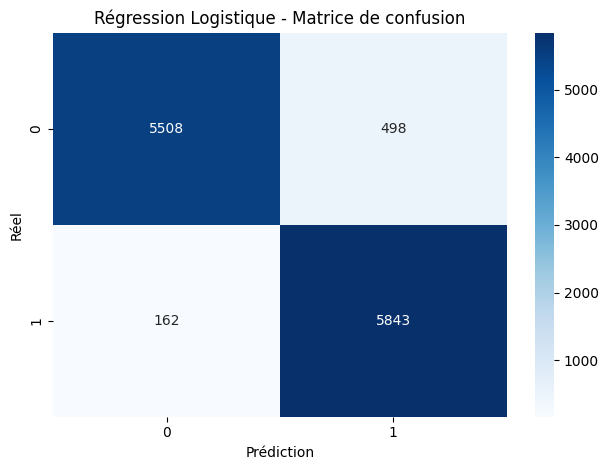

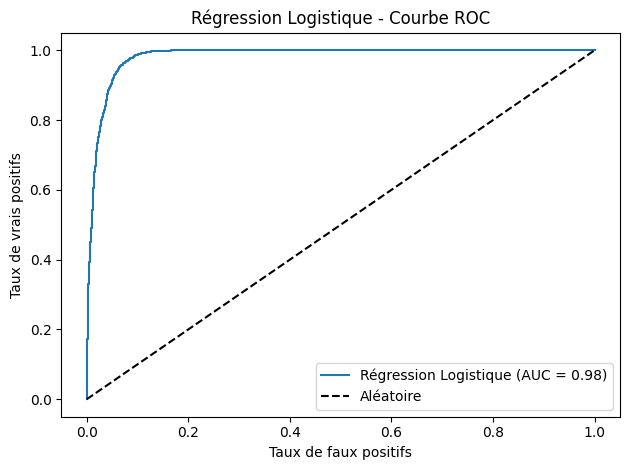


🎯 Entraînement du modèle : Support Vector Machine...

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      6006
           1       0.92      0.98      0.95      6005

    accuracy                           0.94     12011
   macro avg       0.95      0.94      0.94     12011
weighted avg       0.95      0.94      0.94     12011



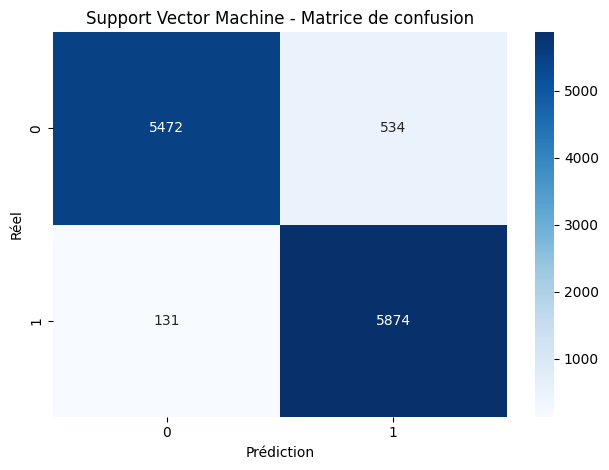

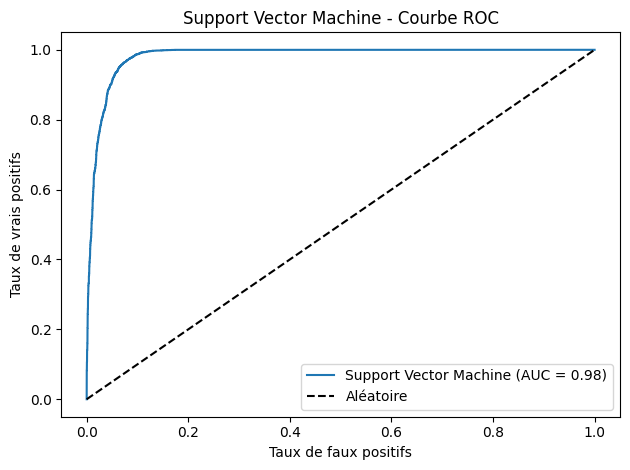


🎯 Entraînement du modèle : Random Forest...

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      6006
           1       0.92      0.97      0.94      6005

    accuracy                           0.94     12011
   macro avg       0.94      0.94      0.94     12011
weighted avg       0.94      0.94      0.94     12011



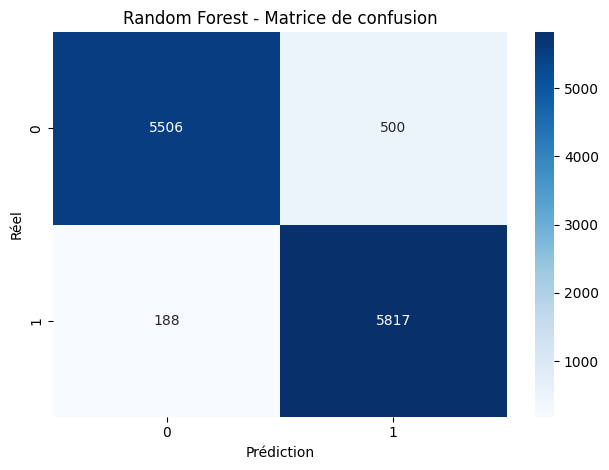

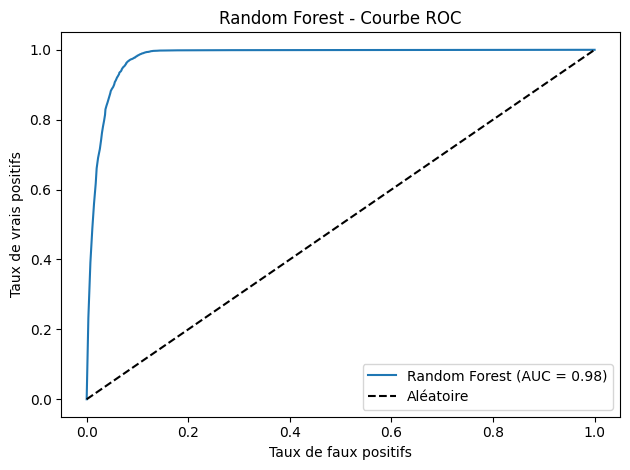


🎯 Entraînement du modèle : XGBoost...

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      6006
           1       0.92      0.97      0.94      6005

    accuracy                           0.94     12011
   macro avg       0.94      0.94      0.94     12011
weighted avg       0.94      0.94      0.94     12011



d:\01-Formation dev IA\02-Projet\SensorGuard\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:46:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


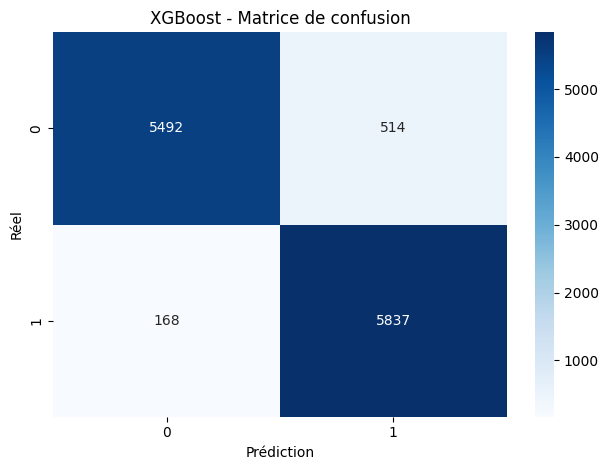

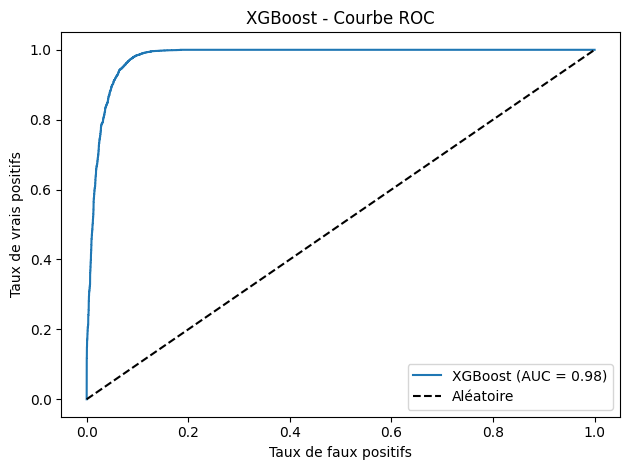

In [15]:
# Définir les modèles candidats
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(kernel="linear", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
}

model_scores = {}
trained_models = {}

for name, model in models.items():
    print(f"\n🎯 Entraînement du modèle : {name}...\n")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Générer et stocker le rapport de classification
    report = classification_report(y_test, y_pred, output_dict=True)
    model_scores[name] = report
    trained_models[name] = model  # Sauvegarder le modèle entraîné

    # Afficher le rapport détaillé
    print(classification_report(y_test, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Matrice de confusion")
    plt.xlabel("Prédiction")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.show()

    # Courbe ROC: évaluation de la capacité du modèle à distinguer les classes
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.title(f"{name} - Courbe ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

### 🎯 Selection du modèle

####  🧠 &nbsp;*Stratégies de selection*
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;🔎 Objectif : Détecter au plus tôt les pannes à 7 jours, en privilégiant la performance sur la classe 1 (pannes), critique en contexte industriel.

##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;***🎯 Critères de priorisation :***<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Principal : Rappel (classe 1) — pour limiter les pannes non détectées (faux négatifs).<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Secondaire : F1-score — équilibre entre rappel et précision, utile en cas de déséquilibre des classes.<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Complémentaire : Précision — pour éviter les fausses alertes et garantir la pertinence des prédictions.





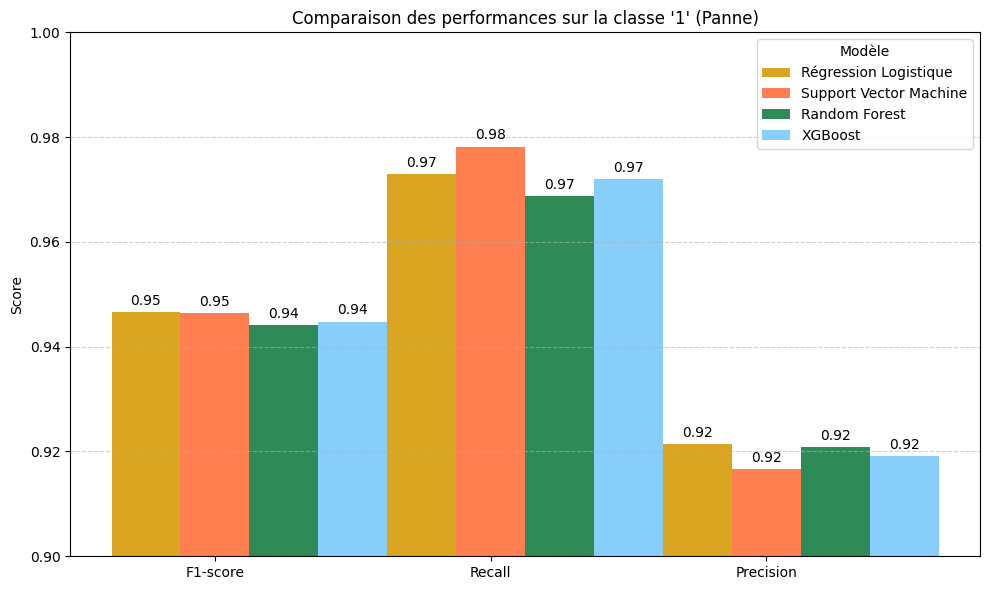

🏆 Meilleur modèle sélectionné : Support Vector Machine
📈 Rappel (classe 1) : 0.98
📊 F1-score (classe 1) : 0.95
🔬 Précision (classe 1) : 0.92


In [22]:
# Afficher les métriques des modèles
metrics = ["f1-score", "recall", "precision"]
model_names = list(model_scores.keys())
scores = {
    metric: [model_scores[model]["1"][metric] for model in model_names]
    for metric in metrics
}

# Tracer le graphique
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["goldenrod", "coral", "seagreen", "lightskyblue"]
rects = []

for i, model_name in enumerate(model_names):
    rect = ax.bar(
        x + (i - 1) * width,
        [scores[m][i] for m in metrics],
        width,
        label=model_name,
        color=colors[i % len(colors)],
    )
    rects.extend(rect)

ax.set_ylabel("Score")
ax.set_title("Comparaison des performances sur la classe '1' (Panne)")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0.90, 1.0)
ax.legend(title="Modèle")
ax.grid(axis="y", linestyle="--", alpha=0.6)

for rect in rects:
    height = rect.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

# Sélectionner le meilleur modèle en priorisant le rappel sur la classe '1' (pannes),
# puis le F1-score, puis la précision
best_model_name = max(
    model_scores,
    key=lambda name: (
        model_scores[name]["1"].get("recall", 0),
        model_scores[name]["1"].get("f1-score", 0),
        model_scores[name]["1"].get("precision", 0),
    ),
)
best_model = trained_models[best_model_name]

print(f"🏆 Meilleur modèle sélectionné : {best_model_name}")
print(f"📈 Rappel (classe 1) : {model_scores[best_model_name]['1']['recall']:.2f}")
print(f"📊 F1-score (classe 1) : {model_scores[best_model_name]['1']['f1-score']:.2f}")
print(f"🔬 Précision (classe 1) : {model_scores[best_model_name]['1']['precision']:.2f}")


### 🎚️ Analyse du seuil de décision pour la prédiction
Bien que les SVM ne soient pas probabilistes par nature, l’option `probability=True` permet d’estimer des probabilités calibrées.<br>Cela autorise l’ajustement du seuil de décision, utile notamment dans les cas de données déséquilibrées ou quand le rappel est prioritaire (comme pour la détection de pannes).<br>Nous analysons ici l’impact de ce seuil sur les performances, notamment l’AUC ROC.

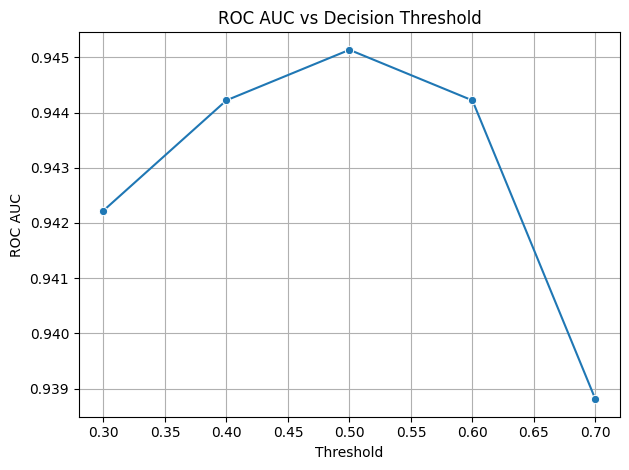

✅ Based on ROC analysis, the default threshold of 0.5 provides optimal balance between precision and recall
No custom threshold adjustment is required.


In [17]:
# Predict probabilities
y_scores = best_model.predict_proba(X_test_scaled)[:, 1]

# Try multiple thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
performance = []

for t in thresholds:
    preds = (y_scores > t).astype(int)
    roc_auc = roc_auc_score(y_test, preds)
    performance.append({"Threshold": t, "ROC AUC": roc_auc})

# Plot the results
perf_df = pd.DataFrame(performance)
sns.lineplot(data=perf_df, x="Threshold", y="ROC AUC", marker="o")
plt.title("ROC AUC vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("ROC AUC")
plt.grid(True)
plt.tight_layout()
plt.show()

print(
    "✅ Based on ROC analysis, the default threshold of 0.5 provides optimal balance between precision and recall"
)
print("No custom threshold adjustment is required.")

### 🧪 Fine-Tuning du modèle SVM avec GridSearch
Le SVM ayant obtenu les meilleurs résultats lors de l’évaluation initiale, une optimisation par validation croisée (GridSearchCV) a été menée.<br>Les noyaux linéaire et RBF ont été testés, ainsi que différentes valeurs du paramètre de régularisation C.<br>Le score ROC AUC a servi de critère pour identifier la configuration la plus efficace pour la détection des pannes.

Fitting 3 folds for each of 6 candidates, totalling 18 fits


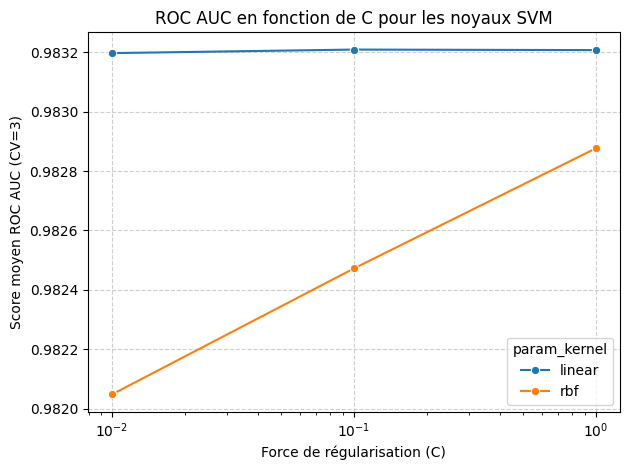

✅ D’après l’optimisation du score ROC AUC, la meilleure configuration du SVM est : C=0.1 avec kernel='linear'.


In [18]:
# Définir la grille d'hyperparamètres incluant les noyaux linéaire et RBF
param_grid = {
    "C": [0.01, 0.1, 1.0],
    "kernel": ["linear", "rbf"],
}

# Recherche par grille avec validation croisée
grid = GridSearchCV(
    SVC(probability=True, class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

# Entraîner le modèle
grid.fit(X_train_scaled, y_train)

# Sélectionner le meilleur modèle
best_model = grid.best_estimator_

# Visualiser les résultats
results = pd.DataFrame(grid.cv_results_)

sns.lineplot(
    data=results,
    x="param_C",
    y="mean_test_score",
    hue="param_kernel",
    marker="o"
)
plt.title("ROC AUC en fonction de C pour les noyaux SVM")
plt.xlabel("Force de régularisation (C)")
plt.ylabel("Score moyen ROC AUC (CV=3)")
plt.xscale("log")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(
    f"✅ D’après l’optimisation du score ROC AUC, la meilleure configuration du SVM est : "
    f"C={grid.best_params_['C']} avec kernel='{grid.best_params_['kernel']}'."
)


### 📈 Courbes ROC et precision/recall

📈 La courbe ROC illustre le compromis entre le taux de vrais positifs (rappel) et le taux de faux positifs selon différents seuils.
✅ L’AUC (aire sous la courbe) résume la capacité du modèle à distinguer les classes. Plus elle est proche de 1.0, meilleur est le modèle.


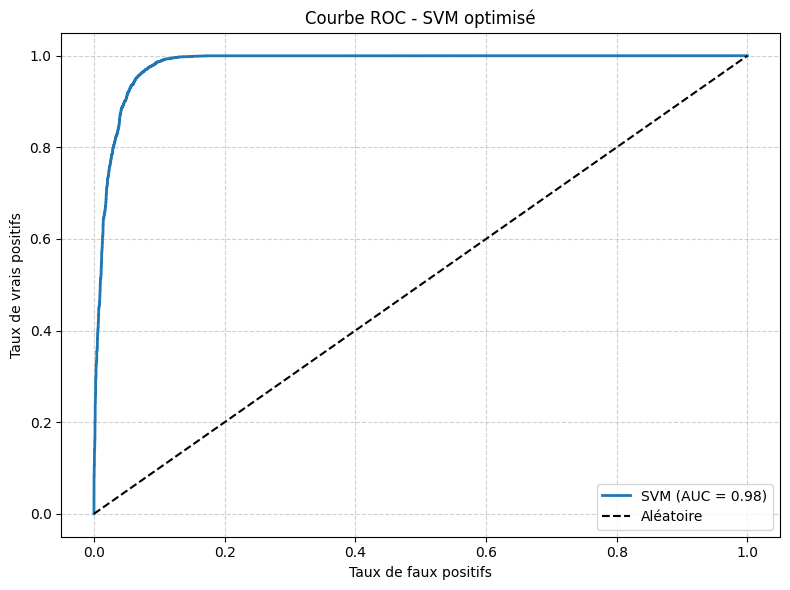

📊 La courbe Précision-Rappel montre le compromis entre la détection des pannes (rappel) et la limitation des fausses alertes (précision).
✅ Particulièrement utile dans les problèmes de classification déséquilibrés comme la prédiction de pannes.


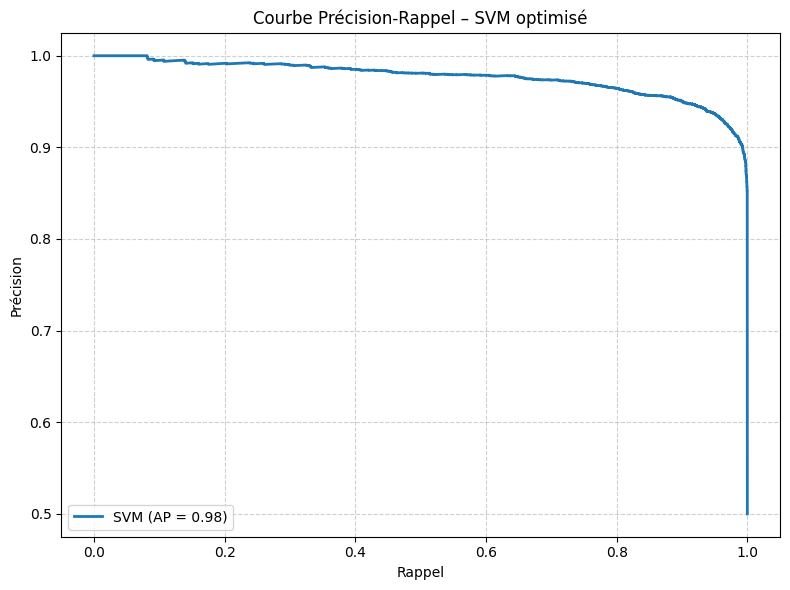

In [19]:
# Obtenir les probabilités prédites pour la classe 1
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculer la courbe ROC et l’AUC
print("📈 La courbe ROC illustre le compromis entre le taux de vrais positifs (rappel) et le taux de faux positifs selon différents seuils.")
print("✅ L’AUC (aire sous la courbe) résume la capacité du modèle à distinguer les classes. Plus elle est proche de 1.0, meilleur est le modèle.")
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Afficher la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - SVM optimisé")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Calculer la courbe précision-rappel et la précision moyenne
print("📊 La courbe Précision-Rappel montre le compromis entre la détection des pannes (rappel) et la limitation des fausses alertes (précision).")
print("✅ Particulièrement utile dans les problèmes de classification déséquilibrés comme la prédiction de pannes.")
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# Afficher la courbe Précision-Rappel
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"SVM (AP = {avg_precision:.2f})", linewidth=2)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel – SVM optimisé")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


### 🔧  Entraînement du modèle SVM final et calibration des probabilités
Nous entraînons le modèle SVM final avec les meilleurs hyperparamètres trouvés via GridSearchCV, en minimisant la hinge loss pour optimiser la classification.<br>Pour obtenir des probabilités bien calibrées, nous appliquons le Platt scaling, qui ajuste une régression logistique sur les scores de décision du SVM en minimisant la log loss.<br> Les pertes sur les ensembles d'entraînement et de test permettent d’évaluer cette calibration et de détecter un éventuel surapprentissage.

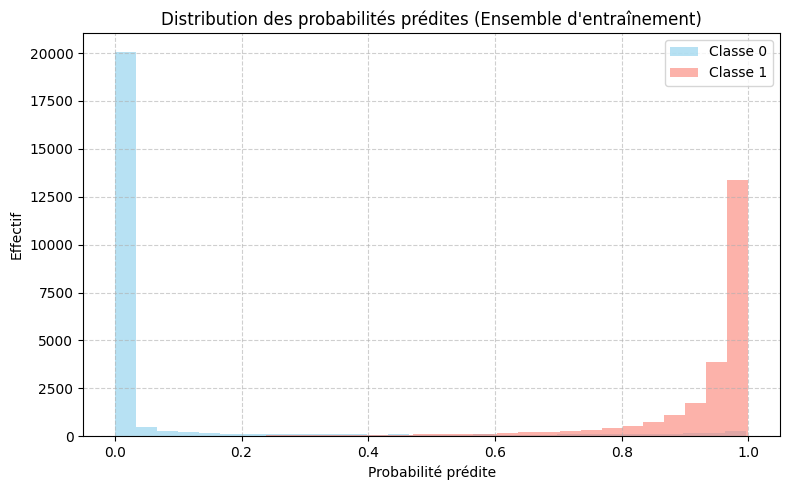

📉 Log loss sur l’ensemble d’entraînement : 0.1392
✅ Interprétation : Très bonne qualité prédictive — modèle bien calibré et discriminant.


In [20]:
# Modèle SVM final (avec les meilleurs hyperparamètres trouvés)
final_model = SVC(
    C=best_model.C,
    kernel=best_model.kernel,
    probability=True,
    class_weight="balanced",
    random_state=42
)

# Entraîner le modèle final sur l’ensemble d’entraînement complet
final_model.fit(X_train_scaled, y_train)

# Évaluer la log loss sur l’ensemble d’entraînement
y_train_prob = final_model.predict_proba(X_train_scaled)
train_log_loss = log_loss(y_train, y_train_prob)

# Afficher l’histogramme des probabilités prédites pour la classe 1
plt.figure(figsize=(8, 5))
plt.hist(y_train_prob[y_train == 0][:, 1], bins=30, alpha=0.6, label="Classe 0", color="skyblue")
plt.hist(y_train_prob[y_train == 1][:, 1], bins=30, alpha=0.6, label="Classe 1", color="salmon")
plt.xlabel("Probabilité prédite")
plt.ylabel("Effectif")
plt.title("Distribution des probabilités prédites (Ensemble d'entraînement)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Interprétation de la log loss
print(f"📉 Log loss sur l’ensemble d’entraînement : {train_log_loss:.4f}")
if train_log_loss < 0.05:
    print("💡 Interprétation : Prédiction quasi parfaite — très grande confiance et excellente précision.")
elif train_log_loss < 0.2:
    print("✅ Interprétation : Très bonne qualité prédictive — modèle bien calibré et discriminant.")
elif train_log_loss < 0.5:
    print("⚠️ Interprétation : Performance modérée — le modèle manque peut-être de confiance ou est perturbé par du bruit.")
elif train_log_loss < 1.0:
    print("❌ Interprétation : Mauvaise qualité prédictive — un ajustement ou une amélioration des features est à envisager.")
else:
    print("🚨 Interprétation : Perte très élevée — les probabilités prédites sont peu fiables.")

###  💾 Sauvegarde du modèle et de son scaler

In [21]:
# Créer le répertoire models/ s’il n’existe pas déjà
os.makedirs("../models", exist_ok=True)

# Rapport d’évaluation
y_pred = final_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Sauvegarder le modèle entraîné
model_path = (
    f'../models/failure_predictor_{best_model_name.replace(" ", "_").lower()}.pkl'
)
joblib.dump(final_model, model_path)
print(f"\n✅ Meilleur modèle ({best_model_name}) sauvegardé dans : {model_path}")

# Sauvegarder également le scaler utilisé
scaler_path = "../models/scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler sauvegardé dans : {scaler_path}")

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      6006
           1       0.91      0.98      0.95      6005

    accuracy                           0.94     12011
   macro avg       0.95      0.94      0.94     12011
weighted avg       0.95      0.94      0.94     12011


✅ Meilleur modèle (Support Vector Machine) sauvegardé dans : ../models/failure_predictor_support_vector_machine.pkl
✅ Scaler sauvegardé dans : ../models/scaler.pkl
